In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader

### Get File path and load the csv data

In [2]:
from util.data_path import cassava_price_avg

In [3]:
wide = pd.read_csv(cassava_price_avg)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [4]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

### Create a sequence dataset class for LSTM prediction

In [5]:
from util.lstm_cust_class import SeqDataset

SEQ_LEN = 12
PRED_LEN = 12

In [6]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

### Create the LSTM regression model class

In [7]:
from util.lstm_cust_class import LSTMRegressor

### Training the LSTM model

In [8]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.00969
epoch 100/300  loss=0.00271
epoch 150/300  loss=0.00173
epoch 200/300  loss=0.00130
epoch 250/300  loss=0.00121
epoch 300/300  loss=0.00119


### Predict the data for the next year

In [9]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2024
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    3.49
2024-02-01    3.32
2024-03-01    3.21
2024-04-01    3.15
2024-05-01    3.08
2024-06-01    3.01
2024-07-01    2.95
2024-08-01    2.90
2024-09-01    2.85
2024-10-01    2.80
2024-11-01    2.76
2024-12-01    2.72
Freq: MS, Name: forecast_price, dtype: float64


In [10]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01    3.65            3.49
2024-02-01    3.65            3.32
2024-03-01    3.57            3.21
2024-04-01    3.24            3.15
2024-05-01    3.19            3.08
2024-06-01    3.09            3.01
2024-07-01    3.06            2.95
2024-08-01    2.95            2.90
2024-09-01    2.86            2.85
2024-10-01    2.65            2.80
2024-11-01    2.60            2.76
2024-12-01    2.32            2.72


### Compare The Error of a predicted data and the actual data in a table format

In [11]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
mae_lstm = mean_absolute_error(cmp["actual"], cmp["forecast_price"])


print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
    }
)
print(error_df.round(4))
print(f"\nOverall Mean Absolute Error: {mae_lstm:.6f}")


--- Monthly Errors ---
            actual  forecast   error  abs_error
2024-01-01    3.65    3.4949  0.1551     0.1551
2024-02-01    3.65    3.3151  0.3349     0.3349
2024-03-01    3.57    3.2122  0.3578     0.3578
2024-04-01    3.24    3.1464  0.0936     0.0936
2024-05-01    3.19    3.0809  0.1091     0.1091
2024-06-01    3.09    3.0144  0.0756     0.0756
2024-07-01    3.06    2.9534  0.1066     0.1066
2024-08-01    2.95    2.8988  0.0512     0.0512
2024-09-01    2.86    2.8489  0.0111     0.0111
2024-10-01    2.65    2.8028 -0.1528     0.1528
2024-11-01    2.60    2.7604 -0.1604     0.1604
2024-12-01    2.32    2.7218 -0.4018     0.4018

Overall Mean Absolute Error: 0.167509


### Plot The predicted data compare to an actual data

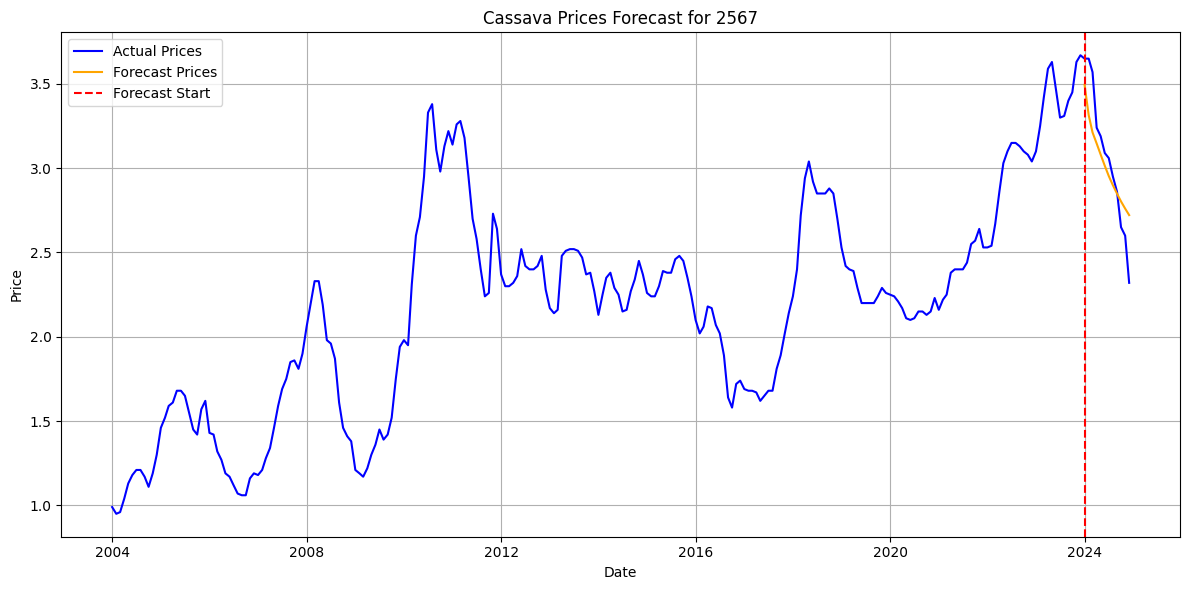

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title("Cassava Prices Forecast for 2567")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()